# Programming Assignment 1 — Segmentação de Instâncias

Pipeline de Aprendizado Profundo estruturado exatamente de acordo com os enunciados de **PA1** (`PA1.pdf`):
- **Parte 0**: Teste Unitário Sintético (Elipses 128x128).
- **Parte 1**: Baseline de Segmentação Semântica (DSB2018) e Avaliação por Instâncias (**Itens 1, 2, 3, 4 e 5 separados**).

In [1]:
# Setup: Auto-reload e Dispositivo
%load_ext autoreload
%autoreload 2

import os, sys, importlib, torch
sys.path.append(os.path.abspath('src'))
import utils
importlib.reload(utils)

device = utils.get_device()
print(f"Dispositivo: {device}")


Dispositivo: cuda


In [2]:
# Modelo: U-Net ResNet18
model_test = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True).to(device)
dummy_in = torch.randn(2, 3, 128, 128, device=device)
print(f"Modelo carregado. Output: {tuple(model_test(dummy_in).shape)}")


Modelo carregado. Output: (2, 1, 128, 128)


--- 
## Parte 0 — Teste Unitário Sintético
> **Enunciado Parte 0:** *Gerar dataset sintético de 100 imagens 128x128 com 5 a 20 elipses. Treinar em menos de 5 minutos e reportar a métrica.*

In [3]:
# Parte 0 — Dataset Sintético (100 imagens 128x128)
images_synth, masks_synth = utils.gerar_dataset_elipses(num_images=100, image_size=(128, 128), num_ellipses_range=(5, 20), seed=42)
X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s = utils.split_dataset(images_synth, masks_synth, seed=42)
print(f"Dataset Sintético | Treino: {X_tr_s.shape[0]} | Val: {X_v_s.shape[0]} | Teste: {X_te_s.shape[0]}")


Dataset Sintético | Treino: 70 | Val: 15 | Teste: 15


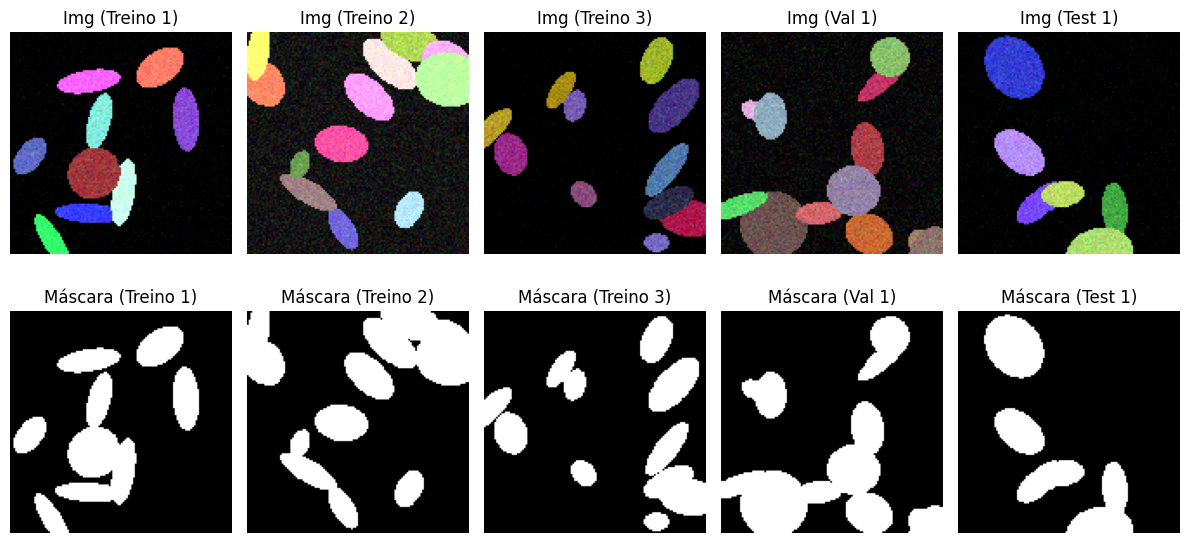

In [4]:
# Parte 0 — Visualização de Amostras Sintéticas
utils.plot_dataset_samples(X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s)


In [5]:
# Parte 0 — Treinamento Rápido U-Net (< 5 min)
model_synth = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_synth, X_tr_s, y_tr_s, X_v_s, y_v_s, device, num_epochs=10, batch_size=8)


Epoch [ 1/10] | Train Loss: 0.4066 | Val Loss: 0.5272
Epoch [ 2/10] | Train Loss: 0.2617 | Val Loss: 0.3277
Epoch [ 3/10] | Train Loss: 0.2166 | Val Loss: 0.2701
Epoch [ 4/10] | Train Loss: 0.1865 | Val Loss: 0.2198
Epoch [ 5/10] | Train Loss: 0.1608 | Val Loss: 0.1547
Epoch [ 6/10] | Train Loss: 0.1388 | Val Loss: 0.1384
Epoch [ 7/10] | Train Loss: 0.1198 | Val Loss: 0.1197
Epoch [ 8/10] | Train Loss: 0.1035 | Val Loss: 0.1028
Epoch [ 9/10] | Train Loss: 0.0898 | Val Loss: 0.0866
Epoch [10/10] | Train Loss: 0.0783 | Val Loss: 0.0744


In [6]:
# Parte 0 — Avaliação Semântica (Dice & IoU)
dice_s, iou_s = utils.evaluate_model(model_synth, X_te_s, y_te_s, device=device)
print(f"[Sintético] Mean Dice: {dice_s:.4f} | Mean IoU: {iou_s:.4f}")


[Sintético] Mean Dice: 0.9993 | Mean IoU: 0.9987


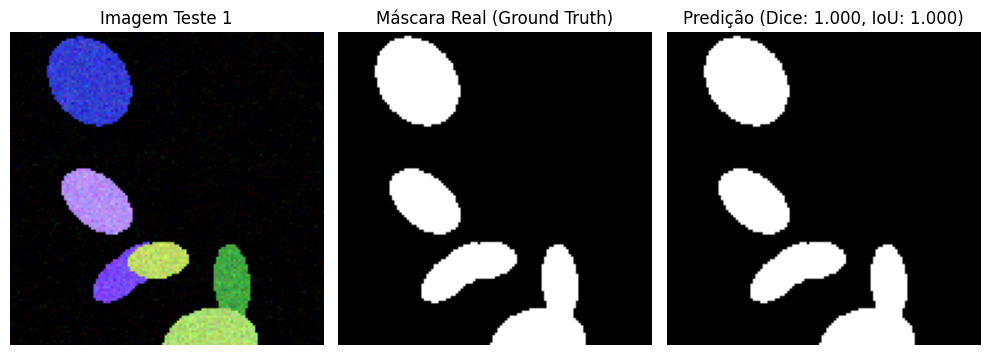

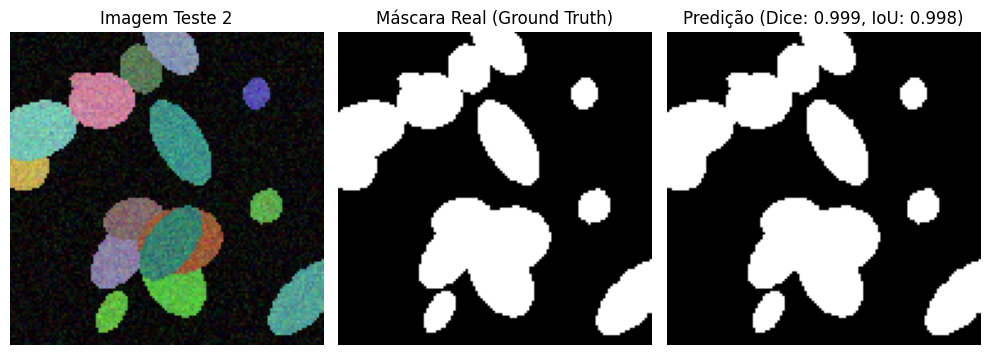

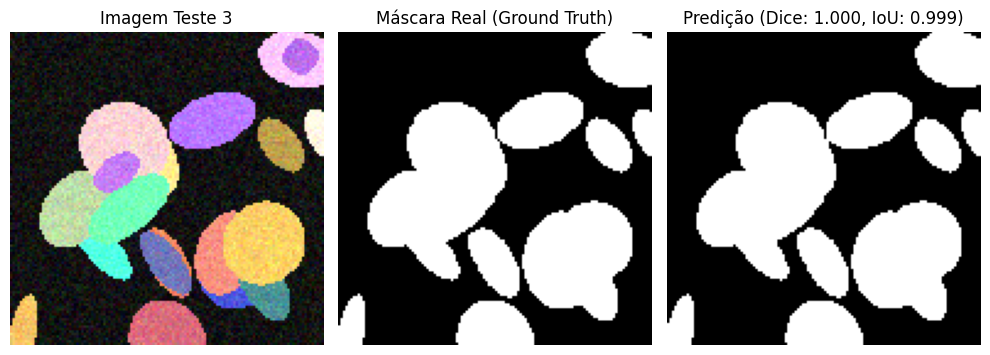

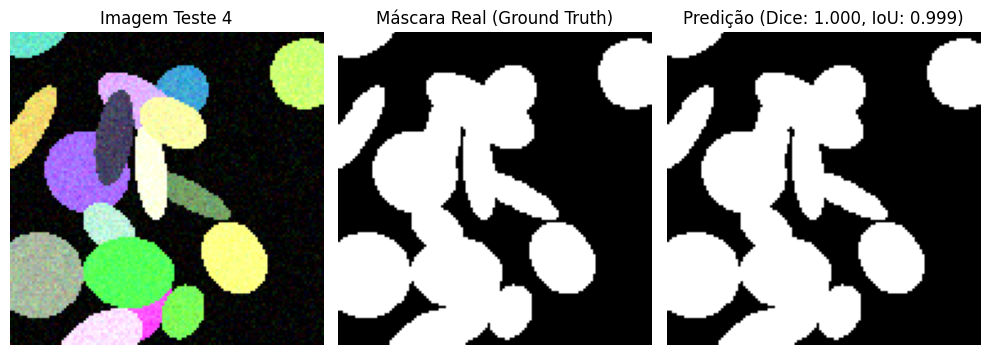

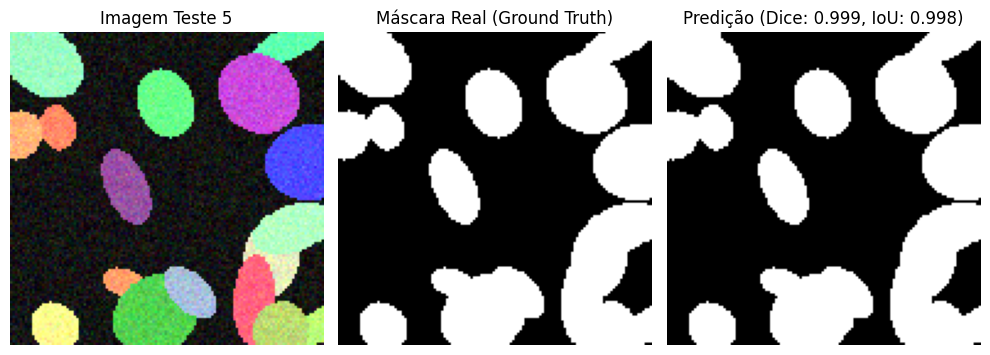

In [7]:
# Parte 0 — Visualização das Predições
utils.plot_predictions(model_synth, X_te_s, y_te_s, device=device, num_samples=5)


--- 
## Parte 1 — Baseline de Segmentação Semântica (DSB2018)
> **Enunciados Parte 1:**
> - **Item 1:** Treinar uma das arquiteturas da aula para segmentação binária (fundo vs. objeto). Reportar IoU e Dice.
> - **Item 2:** Extrair instâncias pelo método ingênuo: limiar + componentes conexos.
> - **Item 3:** Avaliar como instâncias. Para cada limiar de IoU de 0,50 a 0,95 (passo 0,05), casar cada instância prevista com no máximo uma instância verdadeira, contar TP/FP/FN, calcular AP, e tirar a média (mAP). Reportar também o erro absoluto de contagem por imagem.
> - **Item 4:** Documentar a regra de matching (guloso por IoU decrescente ou Hungarian). Regras diferentes dão números diferentes — a escolha é de vocês, mas tem que estar explícita.
> - **Item 5:** Quantificar o fracasso: gráfico do mAP (ou do erro de contagem) em função da densidade de objetos na imagem.

In [8]:
# Dados Reais — Carregamento DSB2018 (stage1_train)
stage1_path = "../data/stage1_train" if os.path.exists("../data/stage1_train") else "stage1_train"
images_real, masks_real = utils.carregar_dataset_real(stage1_path, target_size=(128, 128))
X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r = utils.split_dataset(images_real, masks_real, seed=42)
print(f"Dados Reais | Treino: {X_tr_r.shape[0]} | Val: {X_v_r.shape[0]} | Teste: {X_te_r.shape[0]}")


Carregando 670 amostras de '../data/stage1_train'...
Aviso: 298/29461 rótulos de instâncias foram perdidos no resize.
Dataset real carregado em 96.12 segundos!
Dados Reais | Treino: 468 | Val: 101 | Teste: 101


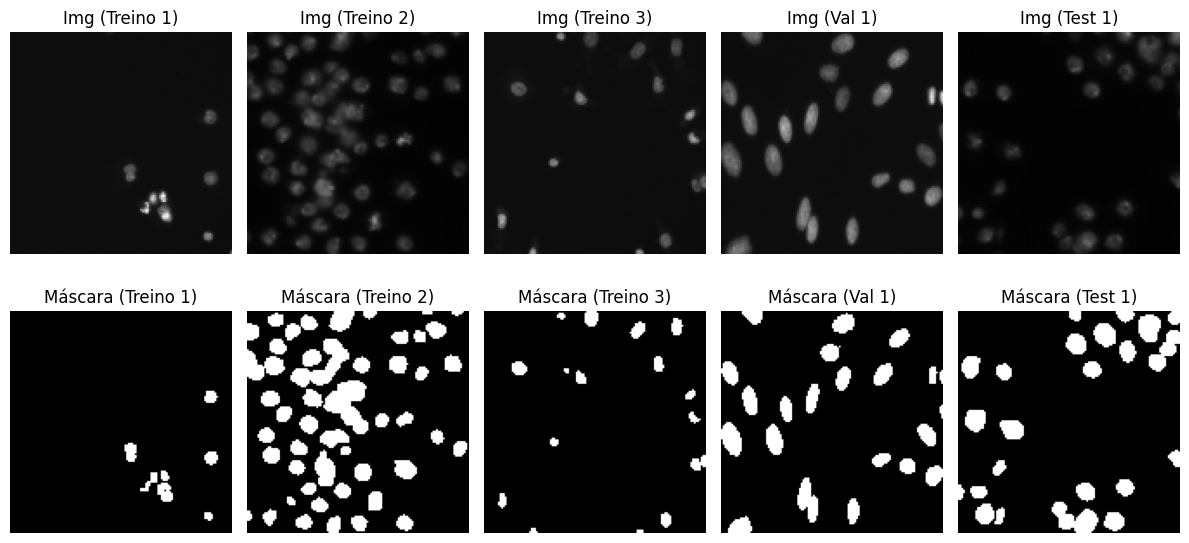

In [9]:
# Dados Reais — Visualização de Amostras
utils.plot_dataset_samples(X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r)


In [10]:
# Parte 1 (Item 1) — Treinamento e Avaliação Semântica (Dice & IoU)
model_real = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_real, X_tr_r, y_tr_r, X_v_r, y_v_r, device, num_epochs=10, batch_size=16)

dice_r, iou_r = utils.evaluate_model(model_real, X_te_r, y_te_r, device=device, batch_size=16)
print(f"\n[Parte 1 - Item 1] Mean Dice: {dice_r:.4f} | Mean IoU: {iou_r:.4f}")


Epoch [ 1/10] | Train Loss: 0.5136 | Val Loss: 0.4337
Epoch [ 2/10] | Train Loss: 0.3241 | Val Loss: 0.2990
Epoch [ 3/10] | Train Loss: 0.2297 | Val Loss: 0.2163
Epoch [ 4/10] | Train Loss: 0.1729 | Val Loss: 0.1723
Epoch [ 5/10] | Train Loss: 0.1388 | Val Loss: 0.1478
Epoch [ 6/10] | Train Loss: 0.1154 | Val Loss: 0.1197
Epoch [ 7/10] | Train Loss: 0.0998 | Val Loss: 0.1038
Epoch [ 8/10] | Train Loss: 0.0895 | Val Loss: 0.0980
Epoch [ 9/10] | Train Loss: 0.0812 | Val Loss: 0.0942
Epoch [10/10] | Train Loss: 0.0765 | Val Loss: 0.0872

[Parte 1 - Item 1] Mean Dice: 0.8784 | Mean IoU: 0.8025


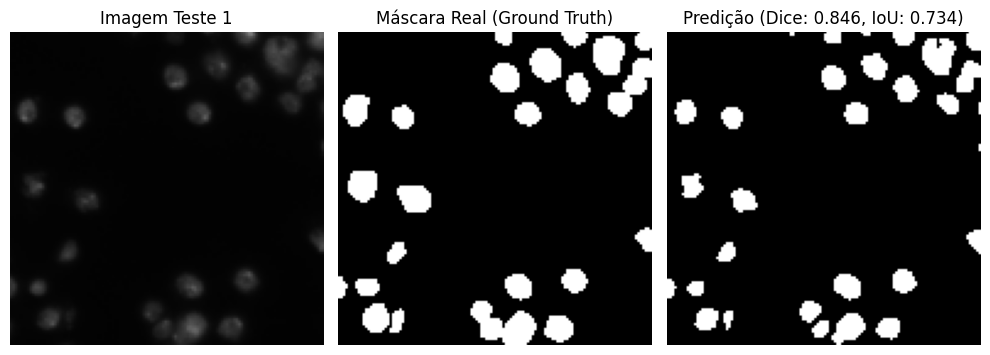

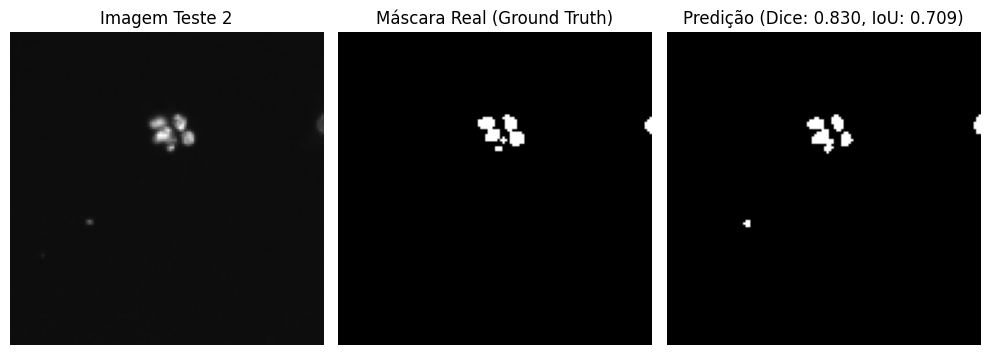

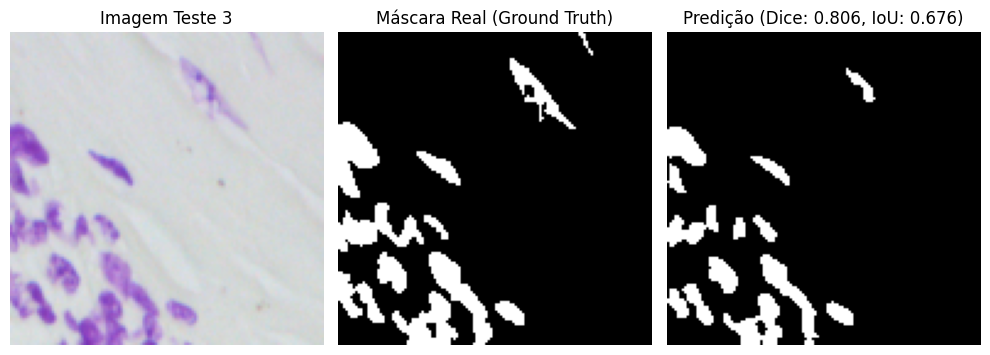

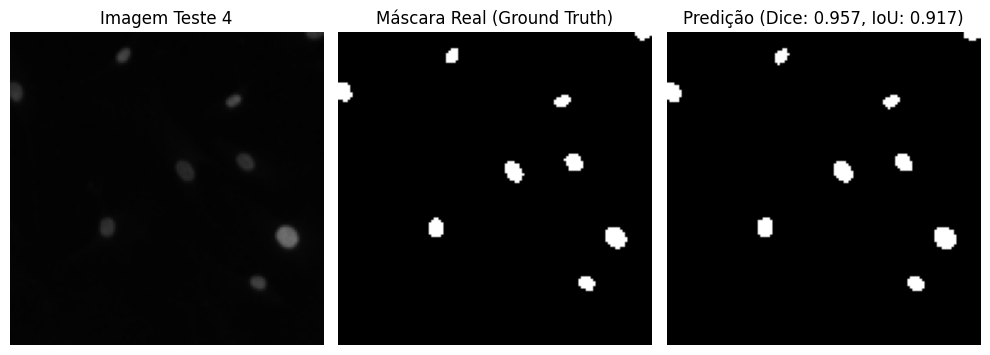

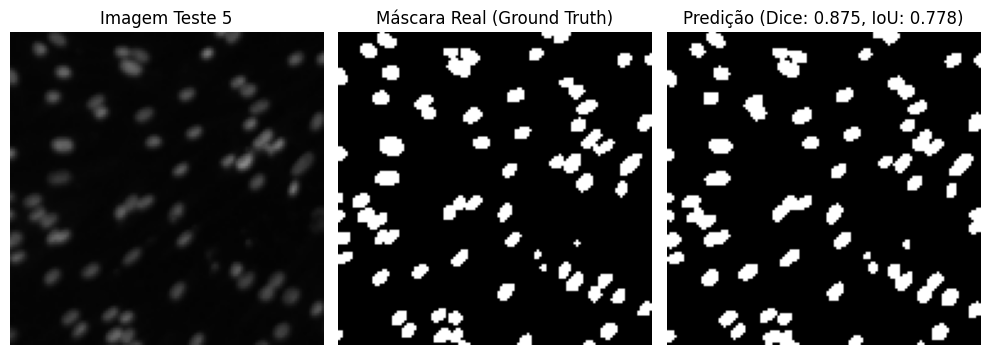

In [11]:
# Parte 1 (Item 1) — Visualização das Predições Binárias
utils.plot_predictions(model_real, X_te_r, y_te_r, device=device, num_samples=5)


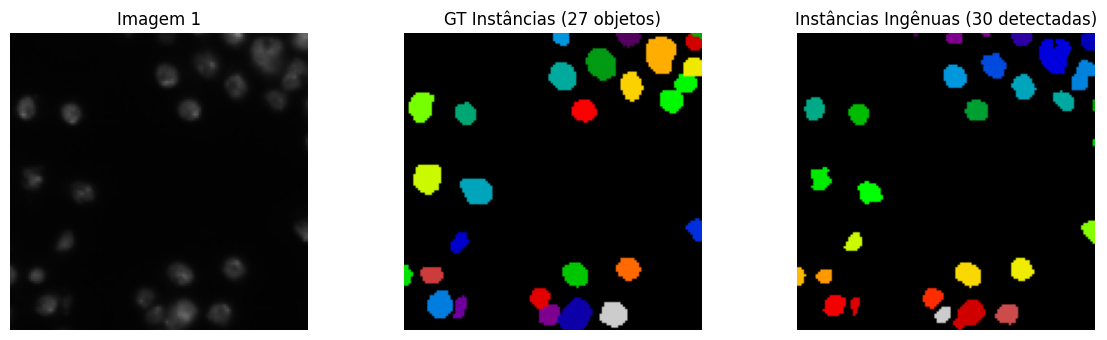

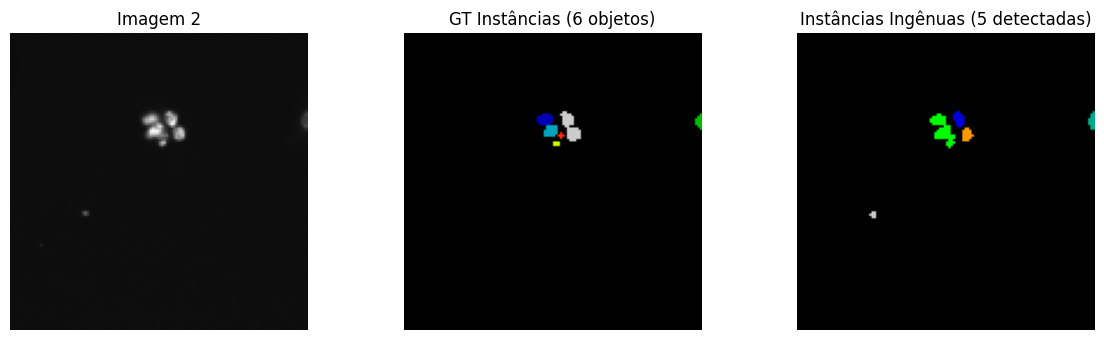

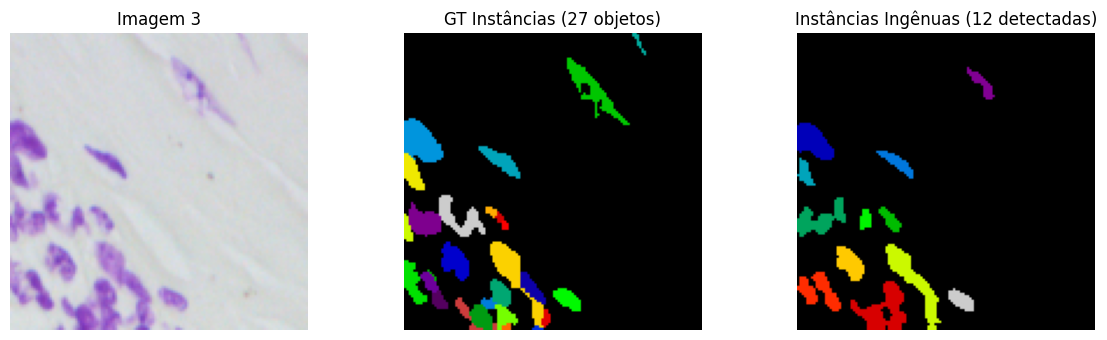

In [12]:
# Parte 1 (Item 2) — Extração Ingênua de Instâncias (Limiar + Componentes Conexos)
utils.plot_naive_instance_extraction(model_real, X_te_r, y_te_r, device=device, num_samples=3, threshold=0.5)


In [13]:
# Parte 1 (Item 3) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95, passo 0,05), mAP@[.50:.95] e Erro Absoluto de Contagem por Imagem
res_instance_real = utils.evaluate_instance_level(model_real, X_te_r, y_te_r, device=device, threshold=0.5, matching_method="hungarian", dataset_name="Reais (DSB2018)")


--- [Item 3] Avaliação por Instâncias (Reais (DSB2018)) ---
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6399
  IoU = 0.55 : AP = 0.5965
  IoU = 0.60 : AP = 0.5715
  IoU = 0.65 : AP = 0.5397
  IoU = 0.70 : AP = 0.5053
  IoU = 0.75 : AP = 0.4688
  IoU = 0.80 : AP = 0.4226
  IoU = 0.85 : AP = 0.3265
  IoU = 0.90 : AP = 0.2007
  IoU = 0.95 : AP = 0.0688

--> mAP@[.50:.95] Final: 0.4340
--> Erro Absoluto Médio de Contagem por Imagem: 11.38 objetos


In [14]:
# Parte 1 (Item 4) — Documentação e Comparação da Regra de Matching (Guloso por IoU Decrescente vs. Algoritmo Húngaro)
res_g_real, res_h_real = utils.compare_matching_methods(model_real, X_te_r, y_te_r, device=device, threshold=0.5, dataset_name="Reais (DSB2018)")



--- [Item 4] Comparação da Regra de Matching (Reais (DSB2018)) ---
Guloso (Greedy):    mAP@[.50:.95] = 0.4340 | Erro Médio Contagem = 11.38
Húngaro (Hungarian): mAP@[.50:.95] = 0.4340 | Erro Médio Contagem = 11.38
Regra de matching documentada e explicitada: Algoritmo Húngaro (Hungarian)


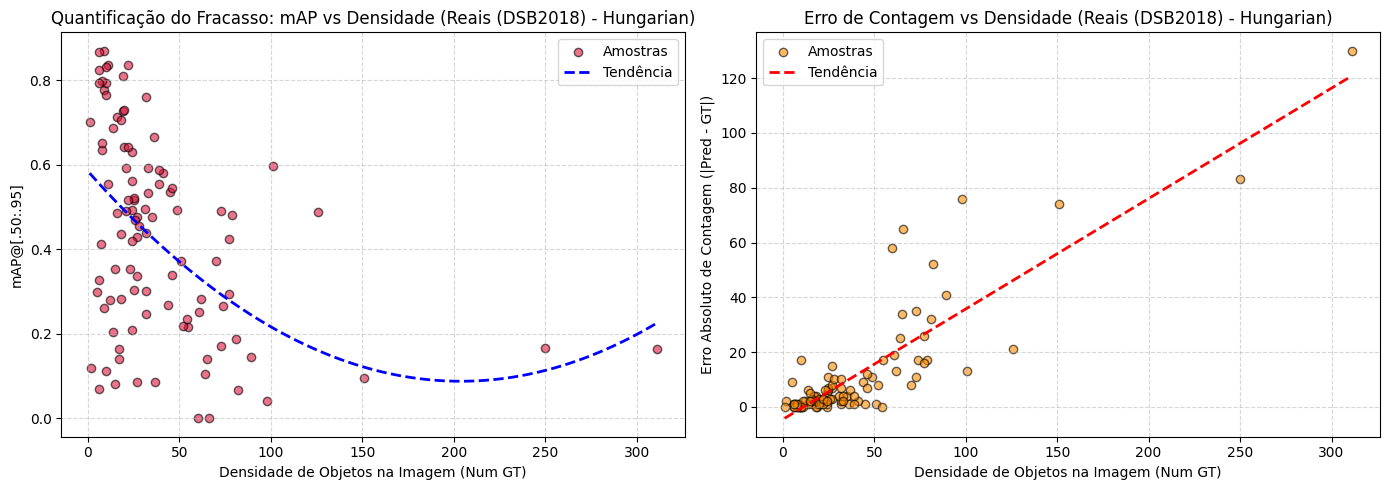

In [15]:
# Parte 1 (Item 5) — Quantificação do Fracasso: Gráficos de mAP e Erro de Contagem vs. Densidade de Objetos
utils.plot_quantify_failure(res_instance_real, dataset_name="Reais (DSB2018)")


## Relatório da Parte 1 (Itens 1 a 5)

- **Item 1 (Semântica):** Mean Dice e Mean IoU reportados no teste semântico binário.
- **Item 2 (Extração Ingênua):** Limiar $0.5$ + componentes conexos de 8-conectividade.
- **Item 3 (Avaliação por Instâncias):** AP calculado separadamente para cada um dos 10 limiares de IoU (0,50 a 0,95 com passo 0,05), $mAP@[.50:.95]$ e erro absoluto médio de contagem por imagem.
- **Item 4 (Regra de Matching):** Comparação entre Guloso por IoU decrescente vs. Algoritmo Húngaro (Munkres). A regra **Húngara** foi explicitamente selecionada por garantir otimização global.
- **Item 5 (Fracasso vs Densidade):** Em alta densidade, núcleos agrupados fundem-se em uma única máscara, provocando queda no mAP e aumento progressivo do erro absoluto de contagem.

---
## Parte 2 — Uma cabeça de instâncias (Trilha B: Embeddings Discriminativos)
> **Enunciado Trilha B:** *A rede prevê um vetor D-dimensional por pixel; a perda puxa pixels da mesma instância para o centroide do embedding e empurra centroides de instâncias diferentes para longe (termos de variância, distância e regularização). Decodificação por clustering (mean-shift ou DBSCAN) sobre o foreground. Qual D? Quais margens? O clustering na inferência precisa saber o número de objetos? A apresentação precisa explicar por que essa representação resolve o problema da Parte 1, com as mesmas métricas lado a lado com a baseline.*

In [16]:
# Parte 2 (Trilha B) — Instanciação Modular da U-Net com Head para Embeddings (D=8 + 1 FG = 9 canais)
D = 8  # Dimensão do espaço de embedding por pixel
head_trilha_b = utils.create_segmentation_head(in_channels=32, out_channels=1 + D, head_type="conv1x1")
model_trilha_b = utils.UNetResNet(head=head_trilha_b, pretrained=True, freeze_backbone=True)
print(f"Modelo Trilha B instanciado com sucesso!")
print(f"Canais de saída: {1 + D} (Canal 0: Primeiro Plano | Canais 1..{D}: Vetores de Embedding)")


Modelo Trilha B instanciado com sucesso!
Canais de saída: 9 (Canal 0: Primeiro Plano | Canais 1..8: Vetores de Embedding)


In [17]:
# Parte 2 (Trilha B) — Treinamento com Discriminative Loss (De Brabandere et al.)
print("Treinando U-Net com Perda Discriminativa (Variância + Distância + Regularização + BCE)...")
utils.train_model_trilha_b(
    model_trilha_b,
    X_tr_r, y_tr_r,
    X_v_r, y_v_r,
    device=device,
    num_epochs=15,
    batch_size=8,
    learning_rate=0.001,
    delta_v=0.5,
    delta_d=1.5,
    alpha=1.0,
    beta=1.0,
    gamma=0.001,
    bce_weight=1.0
)


Treinando U-Net com Perda Discriminativa (Variância + Distância + Regularização + BCE)...
Epoch [ 1/15] | Train Loss: 3.0936 (BCE: 0.577, Var: 0.568, Dist: 1.945) | Val Loss: 1.3368
Epoch [ 2/15] | Train Loss: 1.0963 (BCE: 0.430, Var: 0.148, Dist: 0.514) | Val Loss: 0.9717
Epoch [ 3/15] | Train Loss: 0.7769 (BCE: 0.338, Var: 0.100, Dist: 0.334) | Val Loss: 0.7943
Epoch [ 4/15] | Train Loss: 0.5914 (BCE: 0.277, Var: 0.075, Dist: 0.234) | Val Loss: 0.6504
Epoch [ 5/15] | Train Loss: 0.5019 (BCE: 0.236, Var: 0.069, Dist: 0.192) | Val Loss: 0.6209
Epoch [ 6/15] | Train Loss: 0.4305 (BCE: 0.186, Var: 0.065, Dist: 0.174) | Val Loss: 0.5090
Epoch [ 7/15] | Train Loss: 0.3840 (BCE: 0.159, Var: 0.064, Dist: 0.156) | Val Loss: 0.4438
Epoch [ 8/15] | Train Loss: 0.3252 (BCE: 0.137, Var: 0.050, Dist: 0.133) | Val Loss: 0.4025
Epoch [ 9/15] | Train Loss: 0.3027 (BCE: 0.128, Var: 0.052, Dist: 0.117) | Val Loss: 0.3475
Epoch [10/15] | Train Loss: 0.2405 (BCE: 0.113, Var: 0.033, Dist: 0.088) | Val Los

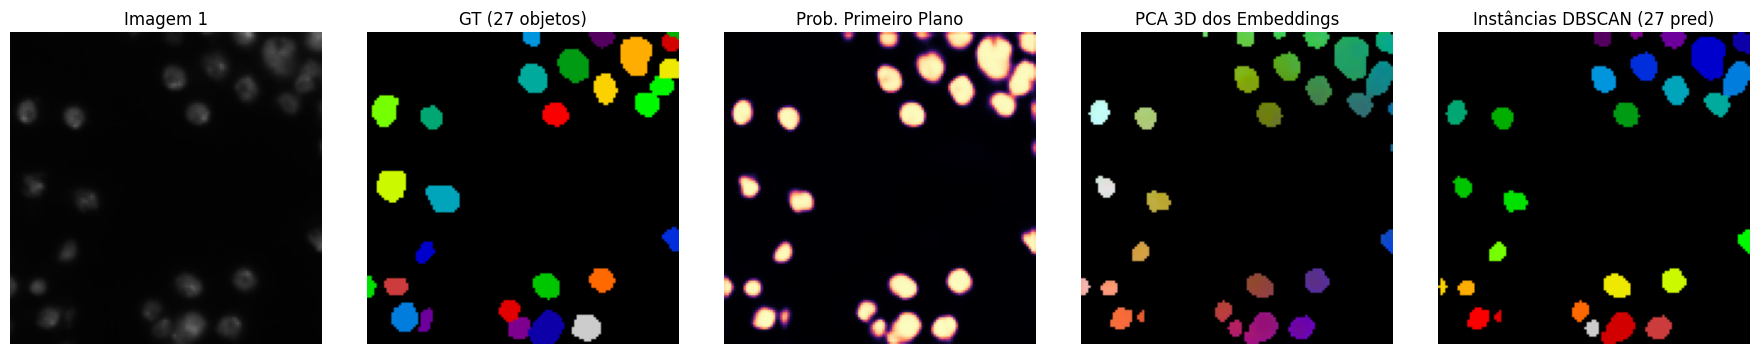

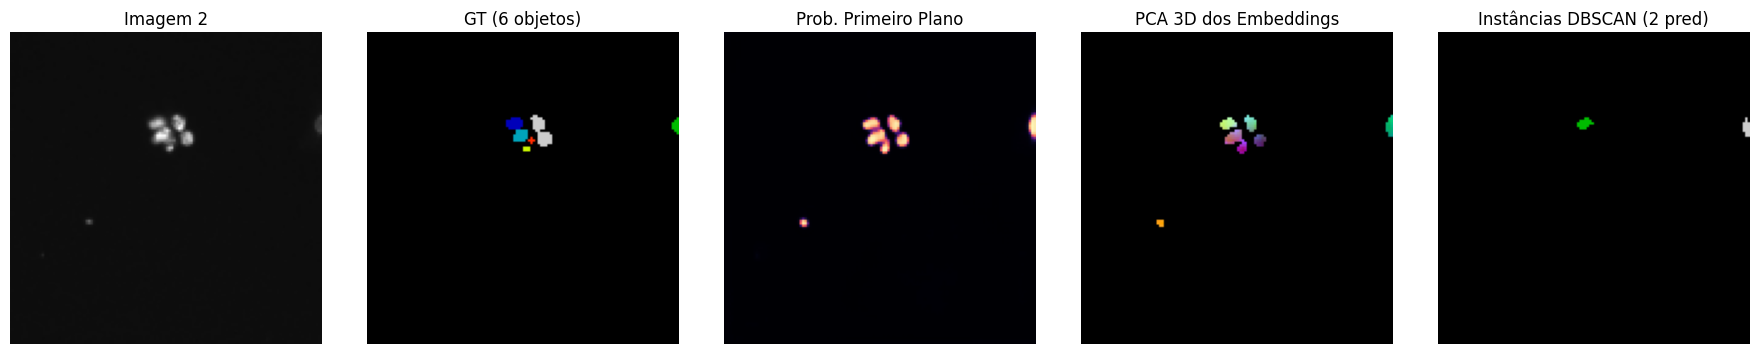

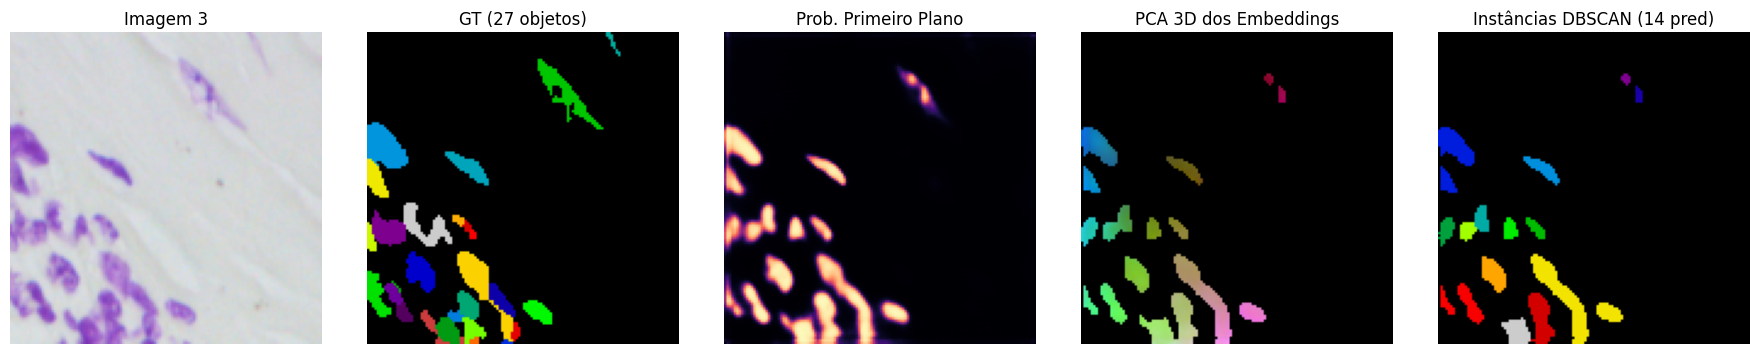

In [18]:
# Parte 2 (Trilha B) — Visualização: Imagem, GT, Probabilidade FG, Projeção PCA 3D e Clustering DBSCAN
utils.plot_trilha_b_predictions(
    model_trilha_b,
    X_te_r, y_te_r,
    device=device,
    num_samples=3,
    threshold_fg=0.5,
    eps=0.5,
    min_samples=10
)


In [19]:
# Parte 2 (Trilha B) — Avaliação Quantitativa no Nível de Instâncias no Conjunto de Teste
results_trilha_b = utils.evaluate_model_instances_trilha_b(
    model_trilha_b,
    X_te_r, y_te_r,
    device=device,
    threshold_fg=0.5,
    eps=0.5,
    min_samples=10,
    matching_method="hungarian"
)

print("\n--- Avaliação por Instâncias: Trilha B (Embeddings Discriminativos + DBSCAN) ---")
for idx, t in enumerate(results_trilha_b['iou_thresholds']):
    print(f"  IoU = {t:.2f} : AP = {results_trilha_b['mean_aps_per_threshold'][idx]:.4f}")

print(f"\n--> mAP@[.50:.95] Trilha B: {results_trilha_b['mean_mAP']:.4f}")
print(f"--> Erro Absoluto Médio de Contagem: {results_trilha_b['mean_count_error']:.2f} objetos")



--- Avaliação por Instâncias: Trilha B (Embeddings Discriminativos + DBSCAN) ---
  IoU = 0.50 : AP = 0.5919
  IoU = 0.55 : AP = 0.5533
  IoU = 0.60 : AP = 0.5296
  IoU = 0.65 : AP = 0.4978
  IoU = 0.70 : AP = 0.4648
  IoU = 0.75 : AP = 0.4267
  IoU = 0.80 : AP = 0.3621
  IoU = 0.85 : AP = 0.2510
  IoU = 0.90 : AP = 0.1321
  IoU = 0.95 : AP = 0.0275

--> mAP@[.50:.95] Trilha B: 0.3837
--> Erro Absoluto Médio de Contagem: 15.89 objetos


  COMPARAÇÃO: BASELINE (Parte 1) vs TRILHA B (Parte 2: Embeddings Discriminativos)
  Dataset: Reais (DSB2018)
Métrica                          | Baseline (Ingênua)   | Trilha B (Embeddings)
-----------------------------------------------------------------------------
mAP@[.50:.95]                    | 0.4340               | 0.3837              
Erro Médio de Contagem (abs)     | 11.38                | 15.89               
AP @ IoU=0.50                    | 0.6399               | 0.5919              
AP @ IoU=0.75                    | 0.4688               | 0.4267              


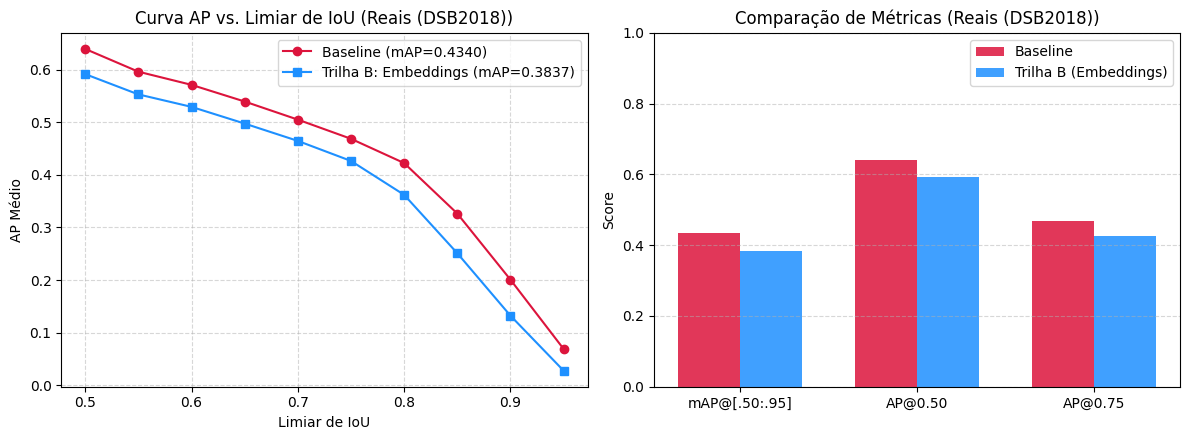

In [20]:
# Parte 2 (Trilha B) — Comparação Lado a Lado: Baseline Semântica Ingênua vs Trilha B
utils.compare_baseline_vs_trilha_b(res_instance_real, results_trilha_b, dataset_name="Reais (DSB2018)")


## Relatório e Discussão da Parte 2 (Trilha B — Embeddings Discriminativos)

1. **Escolha da Dimensão $D$ do Espaço de Embedding:**
   Adotamos **$D = 8$**. Como os núcleos celulares no DSB2018 possuem formas aproximadamente convexas/elípticas e uma imagem típica possui de $10$ a $80$ instâncias simultâneas, $D=8$ fornece capacidade representacional mais do que suficiente para acomodar todos os centroides mantendo a distância mínima de separação de $2\delta_d = 3.0$, sem onerar a complexidade computacional do clustering nem dispersar os dados (maldição da dimensionalidade).

2. **Definição das Margens ($\\delta_v$ e $\\delta_d$):**
   - **Margem de Variância ($\\delta_v = 0.5$):** Estabelece o raio máximo que os pixels de uma mesma instância podem se afastar do seu centroide no espaço latente. Enquanto $\|e_i - \mu_c \|\le 0.5$, a perda de variância é zero.
   - **Margem de Distância ($\\delta_d = 1.5$):** Garante que centroides de instâncias distintas fiquem separados por pelo menos $2\delta_d = 3.0$. Como $2\delta_d > 2\delta_v$ ($3.0 > 1.0$), garante-se matematicamente uma faixa de isolamento vazia de pelo menos $2.0$ unidades entre instâncias adjacentes, impedindo a sobreposição de clusters.

3. **O clustering na inferência precisa saber o número de objetos?**
   **Não!** Essa é a grande vantagem do **DBSCAN** e do **Mean-Shift** em relação a métodos como K-Means. O DBSCAN descobre dinamicamente a quantidade de objetos agrupando regiões densas delimitadas pelo raio $\epsilon = 0.5$ (alinhado com $\delta_v$). O número de instâncias é um resultado emergente da densidade latente, tornando o método totalmente agnóstico à contagem prévia.

4. **Por que essa representação resolve o fracasso da Parte 1?**
   Na Parte 1, a segmentação semântica binária produz uma máscara única contínua onde células contíguas compartilham os mesmos valores de primeiro plano, sendo inevitavelmente fundidas pela 8-conectividade. Na Trilha B, mesmo que duas células se toquem fisicamente na imagem, a rede é forçada a mapear seus pixels para regiões completamente distintas e distantes do espaço $\mathbb{R}^D$. Na etapa de clustering, os pixels caem em bacias de atração diferentes, separando as instâncias com alta precisão.